In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
import os
import re
import geopandas as gpd
from shapely.geometry import Point


In [12]:
df = pd.read_csv('data/processed/borough_master_dataset.csv')

In [13]:
df.head()

,borough_name,gss_code,area_sqkm,population,station_count,crime_total,transaction_count,median_price,mean_price,median_hourly_earnings,jobs_density,bus_stop_count,bus_route_count,crime_rate_per_1000,station_score,bus_route_score,transport_score,population_density
0,Kingston upon Thames,E09000021,37.261178,228514,0,233,2261,525000.0,682561.145511,20.42,0.82,617,33,1.02,0.000000,8.139535,3.26,6133.0
1,Croydon,E09000008,86.494436,490900,6,259,4854,400000.0,482960.377833,20.10,0.57,1608,57,0.53,8.000000,36.046512,19.22,5676.0
2,Bromley,E09000006,150.134858,378948,7,130,4853,480000.0,579193.303524,23.30,0.63,1772,63,0.34,9.333333,43.023256,22.81,2524.0
3,Hounslow,E09000018,55.926233,345756,18,835,2679,466000.0,692836.378126,17.76,0.90,1018,44,2.41,24.000000,20.930233,22.77,6182.0
4,Ealing,E09000009,55.544350,438773,45,542,3929,505000.0,684427.124714,18.59,0.65,958,49,1.24,60.000000,26.744186,46.70,7900.0


In [16]:

# Load borough boundaries
boroughs = gpd.read_file('data/raw/statistical-gis-boundaries-london/ESRI/London_Borough_Excluding_MHW.shp')

print(f"Loaded {len(boroughs)} borough boundaries")
print(f"CRS: {boroughs.crs}")

Loaded 33 borough boundaries
CRS: PROJCS["OSGB36 / British National Grid",GEOGCS["OSGB36",DATUM["Ordnance_Survey_of_Great_Britain_1936",SPHEROID["Airy 1830",6377563.396,299.3249646,AUTHORITY["EPSG","7001"]],AUTHORITY["EPSG","6277"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",49],PARAMETER["central_meridian",-2],PARAMETER["scale_factor",0.999601272],PARAMETER["false_easting",400000],PARAMETER["false_northing",-100000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]


In [17]:
# Create station-borough mapping from raw data
print("Creating station-borough mapping\n")

# Load raw stations
stations_raw = pd.read_csv('data/raw/tfl_stations.csv')
print(f"Loaded {len(stations_raw)} raw station records")

# Deduplicate
stations_unique = stations_raw.drop_duplicates(subset='name', keep='first')
print(f"Deduplicated to {len(stations_unique)} unique stations")

# Convert to GeoDataFrame
from shapely.geometry import Point

geometry = [Point(lon, lat) for lon, lat in zip(stations_unique['lon'], stations_unique['lat'])]
stations_gdf = gpd.GeoDataFrame(
    stations_unique,
    geometry=geometry,
    crs='EPSG:4326'
)

# Transform to match borough CRS
stations_gdf = stations_gdf.to_crs(boroughs.crs)

# Spatial join
stations_with_borough = gpd.sjoin(
    stations_gdf,
    boroughs[['NAME', 'geometry']],
    how='left',
    predicate='within'
)

stations_with_borough = stations_with_borough.rename(columns={'NAME': 'borough'})

# Keep only London stations
stations = stations_with_borough[stations_with_borough['borough'].notna()].copy()

print(f"Matched {len(stations)} stations to boroughs")
print(f"\nSample:")
print(stations[['name', 'borough', 'lat', 'lon']].head())

# Save for future use
stations[['id', 'name', 'lat', 'lon', 'modes', 'borough']].to_csv(
    'data/processed/tfl_stations_with_boroughs.csv', 
    index=False
)
print(f"\nSaved to data/processed/tfl_stations_with_boroughs.csv")

Creating station-borough mapping

Loaded 2646 raw station records
Deduplicated to 957 unique stations
Matched 917 stations to boroughs

Sample:
                         name               borough       lat      lon
21      Acton Central Station                Ealing  51.50862 -0.26351
23            Anerley Station               Bromley  51.41221 -0.06544
25            Barking Station  Barking and Dagenham  51.53944  0.08143
26     Bush Hill Park Station               Enfield  51.64162 -0.06900
28  Barking Riverside Station  Barking and Dagenham  51.51935  0.11663

Saved to data/processed/tfl_stations_with_boroughs.csv


In [18]:
# Verify station-borough assignments make sense
print("Verifying station assignments\n")

# Load the saved file
stations = pd.read_csv('data/processed/tfl_stations_with_boroughs.csv')

# Check a broader sample of well-known stations
print("Sample of well-known stations:")
known_stations = ['King\'s Cross', 'Victoria', 'Liverpool Street', 'Paddington', 
                  'Waterloo', 'Oxford Circus', 'Canary Wharf', 'Stratford',
                  'Brixton', 'Clapham', 'Wimbledon', 'Heathrow']

for station_name in known_stations:
    matches = stations[stations['name'].str.contains(station_name, case=False, na=False)]
    if len(matches) > 0:
        match = matches.iloc[0]
        print(f"  {match['name'][:40]:40s} → {match['borough']}")

print(f"\n--- Stations per Borough (Full List) ---")
station_counts = stations.groupby('borough').size().sort_values(ascending=False)
print(station_counts)

print(f"\n--- Modes Distribution ---")
print(stations['modes'].value_counts())

print(f"\nTotal unique boroughs with stations: {stations['borough'].nunique()}")

Verifying station assignments

Sample of well-known stations:
  King's Cross Station                     → Camden
  Royal Victoria Station                   → Newham
  Liverpool Street Station                 → City of London
  Paddington Underground Station           → Westminster
  Waterloo Underground Station             → Lambeth
  Oxford Circus Station                    → Westminster
  Canary Wharf DLR Station                 → Tower Hamlets
  Stratford Station                        → Newham
  Brixton Station                          → Lambeth
  Clapham High Street                      → Lambeth
  South Wimbledon Station                  → Merton
  Heathrow Terminals 2 & 3 Underground Sta → Hillingdon

--- Stations per Borough (Full List) ---
borough
Westminster               75
Tower Hamlets             67
Brent                     65
Newham                    63
Camden                    56
Ealing                    45
Hammersmith and Fulham    44
Hillingdon                42


In [19]:
# Check Westminster stations in detail
westminster_stations = stations[stations['borough'] == 'Westminster']

print(f"Westminster has {len(westminster_stations)} station records\n")

print("Sample of Westminster stations:")
print(westminster_stations[['name', 'lat', 'lon']].head(20))

print(f"\n--- Checking for duplicates ---")
print(f"Total records: {len(westminster_stations)}")
print(f"Unique names: {westminster_stations['name'].nunique()}")

# Show stations with multiple records
dupes = westminster_stations['name'].value_counts()
dupes_multiple = dupes[dupes > 1]

if len(dupes_multiple) > 0:
    print(f"\nStations still appearing multiple times:")
    print(dupes_multiple)
else:
    print(f"\nNo duplicates found - all 75 are genuinely different stations")
    
# Show geographic spread
print(f"\n--- Geographic Coverage ---")
print(f"Latitude range: {westminster_stations['lat'].min():.4f} to {westminster_stations['lat'].max():.4f}")
print(f"Longitude range: {westminster_stations['lon'].min():.4f} to {westminster_stations['lon'].max():.4f}")

print("\nWestminster borough is large and includes areas:")
print("  - Paddington, Marylebone, Maida Vale (north)")
print("  - Oxford Circus, Piccadilly, Soho (central)")
print("  - Victoria, Westminster, St James's (south)")
print("  - All have multiple stations each")

Westminster has 75 station records

Sample of Westminster stations:
                                      name       lat      lon
165                    Bond Street Station  51.51452 -0.14914
169                   Baker Street Station  51.52246 -0.15695
173                      Bayswater Station  51.51239 -0.18769
178                  Covent Garden Station  51.51307 -0.12423
180                  Charing Cross Station  51.50824 -0.12512
181  Charing Cross Stn  / Trafalgar Square  51.50857 -0.12469
205                     Embankment Station  51.50738 -0.12257
208  Edgware Road Station  / Bakerloo Line  51.52021 -0.17027
209                   Edgware Road Station  51.51967 -0.16803
220                     Green Park Station  51.50673 -0.14274
221          Great Portland Street Station  51.52388 -0.14390
222     Great Portland St Stn  / Euston Rd  51.52374 -0.14370
233               Hyde Park Corner Station  51.50493 -0.15203
247                  Knightsbridge Station  51.50196 -0.16034
25

In [20]:
# Load and process bus route data
print("Processing bus route coverage by borough\n")

import json

# Load bus route stops
with open('data/raw/tfl_bus_route_stops.json', 'r') as f:
    bus_route_stops = json.load(f)

print(f"Loaded {len(bus_route_stops)} bus routes with stop data")

# Convert to flat dataframe
all_stops = []
for route_id, stops in bus_route_stops.items():
    for stop in stops:
        all_stops.append({
            'route_id': route_id,
            'stop_id': stop.get('id'),
            'stop_name': stop.get('commonName'),
            'lat': stop.get('lat'),
            'lon': stop.get('lon')
        })

bus_stops_df = pd.DataFrame(all_stops)
print(f"Total bus stop records: {len(bus_stops_df)}")

# Convert to GeoDataFrame
from shapely.geometry import Point

geometry = [Point(lon, lat) for lon, lat in zip(bus_stops_df['lon'], bus_stops_df['lat'])]
bus_stops_gdf = gpd.GeoDataFrame(
    bus_stops_df,
    geometry=geometry,
    crs='EPSG:4326'
)

bus_stops_gdf = bus_stops_gdf.to_crs(boroughs.crs)

print("Converted to GeoDataFrame and transformed CRS")

# Spatial join
bus_stops_with_borough = gpd.sjoin(
    bus_stops_gdf,
    boroughs[['NAME', 'geometry']],
    how='left',
    predicate='within'
)

bus_stops_with_borough = bus_stops_with_borough.rename(columns={'NAME': 'borough'})

print(f"Matched {bus_stops_with_borough['borough'].notna().sum()} stops to boroughs")

# Calculate metrics
bus_summary = bus_stops_with_borough[bus_stops_with_borough['borough'].notna()].groupby('borough').agg({
    'stop_id': 'nunique',  # Unique stops
    'route_id': 'nunique'  # Unique routes
}).reset_index()

bus_summary.columns = ['borough', 'unique_stops', 'unique_routes']
bus_summary = bus_summary.sort_values('unique_routes', ascending=False)

print(f"\nBus coverage by borough (top 10):")
print(bus_summary.head(10))

Processing bus route coverage by borough

Loaded 508 bus routes with stop data
Total bus stop records: 65842
Converted to GeoDataFrame and transformed CRS
Matched 64304 stops to boroughs

Bus coverage by borough (top 10):
        borough  unique_stops  unique_routes
32  Westminster           632             88
5        Camden           544             69
1        Barnet          1554             66
21      Lambeth           877             63
27    Southwark           887             59
31   Wandsworth           744             54
3         Brent           825             52
4       Bromley          1743             52
22     Lewisham           883             50
11      Hackney           697             48


In [21]:
# Identify and retry missing bus routes
print("Identifying missing bus routes\n")

# Load original route list
bus_routes_all = pd.read_csv('data/raw/tfl_bus_routes.csv')
print(f"Original route list: {len(bus_routes_all)} routes")

# Load collected stops
import json
with open('data/raw/tfl_bus_route_stops.json', 'r') as f:
    collected_stops = json.load(f)

collected_route_ids = set(collected_stops.keys())
print(f"Successfully collected: {len(collected_route_ids)} routes")

# Find missing
all_route_ids = set(bus_routes_all['route_id'].astype(str))
missing_route_ids = all_route_ids - collected_route_ids

print(f"Missing: {len(missing_route_ids)} routes")
print(f"\nSample of missing routes: {sorted(list(missing_route_ids))[:20]}")

# Attempt to collect missing routes
import requests
import time

print(f"\nAttempting to collect {len(missing_route_ids)} missing routes...")
print("This will take ~2-3 minutes\n")

new_collected = 0
still_failed = 0

for idx, route_id in enumerate(sorted(missing_route_ids)):
    if (idx + 1) % 20 == 0:
        print(f"Progress: {idx+1}/{len(missing_route_ids)}")
    
    try:
        url = f"https://api.tfl.gov.uk/Line/{route_id}/StopPoints"
        response = requests.get(url, timeout=10)
        
        if response.status_code == 200:
            stops = response.json()
            if len(stops) > 0:  # Only add if there are actual stops
                collected_stops[route_id] = stops
                new_collected += 1
        else:
            still_failed += 1
    except:
        still_failed += 1
    
    time.sleep(0.5)

# Save updated collection
with open('data/raw/tfl_bus_route_stops.json', 'w') as f:
    json.dump(collected_stops, f, indent=2)

print(f"\nRetry complete!")
print(f"  Newly collected: {new_collected}")
print(f"  Still failed: {still_failed}")
print(f"  Total routes now: {len(collected_stops)}")

Identifying missing bus routes

Original route list: 677 routes
Successfully collected: 508 routes
Missing: 169 routes

Sample of missing routes: ['145', '146', '147', '148', '149', '15', '150', '151', '152', '153', '154', '155', '156', '157', '158', '159', '16', '160', '161', '162']

Attempting to collect 169 missing routes...
This will take ~2-3 minutes

Progress: 20/169
Progress: 40/169
Progress: 60/169
Progress: 80/169
Progress: 100/169
Progress: 120/169
Progress: 140/169
Progress: 160/169

Retry complete!
  Newly collected: 140
  Still failed: 29
  Total routes now: 648


In [22]:

# Check new file size
file_size = os.path.getsize('data/raw/tfl_bus_route_stops.json') / (1024**2)
print(f"Updated file size: {file_size:.1f} MB")

# Count total stops
total_stops = sum(len(stops) for stops in collected_stops.values())
print(f"Total bus stops now: {total_stops:,}")

print(f"\nCoverage summary:")
print(f"  Routes collected: 648/677 (95.7%)")
print(f"  Routes missing: 29 (4.3%)")

# Check which are still missing
still_missing = all_route_ids - set(collected_stops.keys())
print(f"\nStill missing routes: {sorted(list(still_missing))}")

Updated file size: 583.5 MB
Total bus stops now: 82,811

Coverage summary:
  Routes collected: 648/677 (95.7%)
  Routes missing: 29 (4.3%)

Still missing routes: ['284', '285', '286', '287', '288', '289', '29', '291', '292', '293', '474', '484', '496', '499', '67', '670', '672', '68', '696', '88', '89', '90', 'el1', 'g1', 'n109', 'n11', 'n18', 'n19', 'n199']


In [23]:
# Reprocess bus stops with improved coverage
print("Reprocessing bus data with 648 routes\n")

# Convert to flat dataframe
all_stops = []
for route_id, stops in collected_stops.items():
    for stop in stops:
        all_stops.append({
            'route_id': route_id,
            'stop_id': stop.get('id'),
            'stop_name': stop.get('commonName'),
            'lat': stop.get('lat'),
            'lon': stop.get('lon')
        })

bus_stops_df = pd.DataFrame(all_stops)
print(f"Total stop records: {len(bus_stops_df):,}")
print(f"Unique stops: {bus_stops_df['stop_id'].nunique():,}")

# Convert to GeoDataFrame
from shapely.geometry import Point

geometry = [Point(lon, lat) for lon, lat in zip(bus_stops_df['lon'], bus_stops_df['lat'])]
bus_stops_gdf = gpd.GeoDataFrame(bus_stops_df, geometry=geometry, crs='EPSG:4326')
bus_stops_gdf = bus_stops_gdf.to_crs(boroughs.crs)

# Spatial join
bus_stops_with_borough = gpd.sjoin(
    bus_stops_gdf,
    boroughs[['NAME', 'geometry']],
    how='left',
    predicate='within'
)

print(f"Matched {bus_stops_with_borough['NAME'].notna().sum():,} to boroughs")

# Save for connectivity analysis
bus_stops_with_borough.to_csv('data/processed/bus_stops_with_boroughs.csv', index=False)
print(f"\nSaved to data/processed/bus_stops_with_boroughs.csv")

Reprocessing bus data with 648 routes

Total stop records: 82,811
Unique stops: 30,264
Matched 80,746 to boroughs

Saved to data/processed/bus_stops_with_boroughs.csv


In [24]:
# Check for potential issues with stop counting
print("Investigating stop count discrepancy\n")

# Check for stops with same/very similar coordinates
print("Checking for directional duplicates (same location, different stop IDs)...")

# Round coordinates to 4 decimal places (~11 meters precision)
bus_stops_df['lat_rounded'] = bus_stops_df['lat'].round(4)
bus_stops_df['lon_rounded'] = bus_stops_df['lon'].round(4)

# Count unique locations vs unique stop IDs
unique_locations = bus_stops_df.groupby(['lat_rounded', 'lon_rounded']).size().reset_index(name='stop_ids_at_location')
print(f"Unique physical locations (rounded): {len(unique_locations)}")
print(f"Unique stop IDs: {bus_stops_df['stop_id'].nunique()}")
print(f"Difference: {bus_stops_df['stop_id'].nunique() - len(unique_locations)}")

# Show examples of same location with multiple stop IDs
multiple_ids = unique_locations[unique_locations['stop_ids_at_location'] > 1].sort_values('stop_ids_at_location', ascending=False)
print(f"\nLocations with multiple stop IDs (likely directional stops): {len(multiple_ids)}")
print(f"\nTop 10 locations with most stop ID variants:")
print(multiple_ids.head(10))

# Get example of a location with multiple IDs
if len(multiple_ids) > 0:
    example_lat = multiple_ids.iloc[0]['lat_rounded']
    example_lon = multiple_ids.iloc[0]['lon_rounded']
    
    example_stops = bus_stops_df[
        (bus_stops_df['lat_rounded'] == example_lat) & 
        (bus_stops_df['lon_rounded'] == example_lon)
    ]
    
    print(f"\nExample: Same location with {len(example_stops)} different stop IDs:")
    print(example_stops[['stop_name', 'stop_id', 'lat', 'lon']].drop_duplicates('stop_id'))

Investigating stop count discrepancy

Checking for directional duplicates (same location, different stop IDs)...
Unique physical locations (rounded): 19813
Unique stop IDs: 30264
Difference: 10451

Locations with multiple stop IDs (likely directional stops): 16263

Top 10 locations with most stop ID variants:
       lat_rounded  lon_rounded  stop_ids_at_location
10493      51.5108      -0.1205                    40
10460      51.5104      -0.1218                    40
7301       51.4694      -0.3580                    40
14499      51.5578       0.0740                    40
10400      51.5097      -0.1232                    40
10629      51.5123      -0.1188                    39
15849      51.5768       0.1832                    38
9429       51.4961      -0.1013                    36
3155       51.4042       0.0185                    35
11094      51.5176      -0.1243                    34

Example: Same location with 40 different stop IDs:
         stop_name     stop_id       lat   

In [25]:
# Deduplicate bus stops by physical location
print("Deduplicating bus stops by physical location\n")

# Use rounded coordinates to identify same physical location
bus_stops_unique = bus_stops_df.drop_duplicates(subset=['lat_rounded', 'lon_rounded'], keep='first')

print(f"Before deduplication: {len(bus_stops_df):,} stop records")
print(f"After deduplication: {len(bus_stops_unique):,} unique physical locations")
print(f"Removed: {len(bus_stops_df) - len(bus_stops_unique):,} directional duplicates")

# Now redo spatial join with deduplicated stops
geometry = [Point(lon, lat) for lon, lat in zip(bus_stops_unique['lon'], bus_stops_unique['lat'])]
bus_stops_unique_gdf = gpd.GeoDataFrame(bus_stops_unique, geometry=geometry, crs='EPSG:4326')
bus_stops_unique_gdf = bus_stops_unique_gdf.to_crs(boroughs.crs)

bus_stops_clean = gpd.sjoin(
    bus_stops_unique_gdf,
    boroughs[['NAME', 'geometry']],
    how='left',
    predicate='within'
)

bus_stops_clean = bus_stops_clean.rename(columns={'NAME': 'borough'})

print(f"\nMatched {bus_stops_clean['borough'].notna().sum():,} unique stops to boroughs")

# Calculate corrected metrics
bus_summary_corrected = bus_stops_clean[bus_stops_clean['borough'].notna()].groupby('borough').agg({
    'stop_id': 'nunique',
    'route_id': 'nunique'
}).reset_index()

bus_summary_corrected.columns = ['borough', 'unique_stops', 'unique_routes']
bus_summary_corrected = bus_summary_corrected.sort_values('unique_routes', ascending=False)

print(f"\nCorrected bus coverage (top 10):")
print(bus_summary_corrected.head(10))

print(f"\nComparison for Westminster:")
print(f"  Before: 632 stops")
print(f"  After deduplication: {bus_summary_corrected[bus_summary_corrected['borough']=='Westminster']['unique_stops'].values[0]} stops")

Deduplicating bus stops by physical location

Before deduplication: 82,811 stop records
After deduplication: 19,813 unique physical locations
Removed: 62,998 directional duplicates

Matched 18,709 unique stops to boroughs

Corrected bus coverage (top 10):
        borough  unique_stops  unique_routes
32  Westminster           436             57
1        Barnet          1038             53
4       Bromley          1214             49
27    Southwark           617             46
7       Croydon          1055             46
3         Brent           613             44
5        Camden           423             44
31   Wandsworth           520             42
22     Lewisham           608             42
21      Lambeth           589             40

Comparison for Westminster:
  Before: 632 stops
  After deduplication: 436 stops


In [26]:
# Update master dataset with corrected bus counts
print("Updating master dataset with corrected bus metrics\n")

# Merge corrected bus data into master
bus_summary_corrected = bus_summary_corrected.rename(columns={'borough': 'borough_name'})

# Check what we have now vs before
print("Corrected bus metrics:")
print(bus_summary_corrected[['borough_name', 'unique_stops', 'unique_routes']].head(10))

# Save corrected bus summary
bus_summary_corrected.to_csv('data/processed/bus_coverage_corrected.csv', index=False)
print("\nSaved corrected bus coverage to data/processed/bus_coverage_corrected.csv")

# Compare with original master dataset
comparison = df[['borough_name', 'bus_stop_count', 'bus_route_count']].merge(
    bus_summary_corrected, 
    on='borough_name', 
    how='left',
    suffixes=('_old', '_new')
)

print("\nComparison (old vs new counts):")
print(comparison.head(10))

Updating master dataset with corrected bus metrics

Corrected bus metrics:
   borough_name  unique_stops  unique_routes
32  Westminster           436             57
1        Barnet          1038             53
4       Bromley          1214             49
27    Southwark           617             46
7       Croydon          1055             46
3         Brent           613             44
5        Camden           423             44
31   Wandsworth           520             42
22     Lewisham           608             42
21      Lambeth           589             40

Saved corrected bus coverage to data/processed/bus_coverage_corrected.csv

Comparison (old vs new counts):
           borough_name  bus_stop_count  bus_route_count  unique_stops  \
0  Kingston upon Thames             617               33           403   
1               Croydon            1608               57          1055   
2               Bromley            1772               63          1214   
3              Hounslow   

In [27]:
# Update master dataset with corrected bus metrics
print("Updating master dataset with corrected bus data\n")

# Drop old bus columns from master
df_updated = df.drop(columns=['bus_stop_count', 'bus_route_count', 'bus_route_score'])

# Merge in corrected bus data
df_updated = df_updated.merge(
    bus_summary_corrected[['borough_name', 'unique_stops', 'unique_routes']], 
    on='borough_name', 
    how='left'
)

# Rename for consistency
df_updated = df_updated.rename(columns={
    'unique_stops': 'bus_stop_count',
    'unique_routes': 'bus_route_count'
})

# Recalculate bus route score and transport score
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

df_updated['bus_route_score'] = scaler.fit_transform(df_updated[['bus_route_count']]) * 100
df_updated['transport_score'] = (
    df_updated['station_score'] * 0.6 + 
    df_updated['bus_route_score'] * 0.4
).round(2)

print("Recalculated transport scores with corrected bus data")
print(df_updated[['borough_name', 'station_count', 'bus_stop_count', 'bus_route_count', 'transport_score']].head(10))

# Save updated master
df_updated.to_csv('data/processed/borough_master_dataset.csv', index=False)
print("\nUpdated master dataset saved")

# Update df variable
df = df_updated

Updating master dataset with corrected bus data

Recalculated transport scores with corrected bus data
           borough_name  station_count  bus_stop_count  bus_route_count  \
0  Kingston upon Thames              0             403               24   
1               Croydon              6            1055               46   
2               Bromley              7            1214               49   
3              Hounslow             18             677               35   
4                Ealing             45             727               39   
5              Havering             19             666               25   
6            Hillingdon             42             759               36   
7                Harrow             26             454               28   
8                 Brent             65             613               44   
9                Barnet             28            1038               53   

   transport_score  
0             4.32  
1            32.91  
2       

In [28]:
# Analyze rail vs bus reliance patterns
print("Transport Mix Analysis: Rail vs Bus Reliance\n")

# Categorize boroughs by transport type
df['transport_type'] = 'Mixed'
df.loc[df['station_count'] == 0, 'transport_type'] = 'Bus Only'
df.loc[(df['station_count'] > 30) & (df['bus_route_count'] > 40), 'transport_type'] = 'Rail + Bus Hub'
df.loc[(df['station_count'] > 40) & (df['bus_route_count'] < 30), 'transport_type'] = 'Rail Dependent'

print("Borough categories:")
print(df['transport_type'].value_counts())





Transport Mix Analysis: Rail vs Bus Reliance

Borough categories:
transport_type
Mixed             26
Bus Only           3
Rail + Bus Hub     3
Rail Dependent     1
Name: count, dtype: int64


In [29]:
print("\n--- Bus Only Boroughs (No Rail Stations) ---")
bus_only = df[df['transport_type'] == 'Bus Only'][['borough_name', 'bus_stop_count', 'bus_route_count', 'transport_score']]
print(bus_only)

print("\n--- Rail + Bus Hubs (Best Connected) ---")
hubs = df[df['transport_type'] == 'Rail + Bus Hub'][['borough_name', 'station_count', 'bus_route_count', 'transport_score']]
print(hubs.sort_values('transport_score', ascending=False))


--- Bus Only Boroughs (No Rail Stations) ---
            borough_name  bus_stop_count  bus_route_count  transport_score
0   Kingston upon Thames             403               24             4.32
14                Bexley             677               32            12.97
18                Sutton             451               21             1.08

--- Rail + Bus Hubs (Best Connected) ---
   borough_name  station_count  bus_route_count  transport_score
24  Westminster             75               57           100.00
8         Brent             65               44            77.95
25       Camden             57               44            71.55


In [30]:
# Calculate rail dependency ratio
df['rail_dependency'] = df['station_score'] / (df['station_score'] + df['bus_route_score'] + 0.01)  # Avoid division by zero

print("\n--- Most Rail Dependent (High stations, low buses) ---")
print(df.nlargest(5, 'rail_dependency')[['borough_name', 'station_count', 'bus_route_count', 'rail_dependency']])

print("\n--- Most Bus Dependent (Low stations, high buses) ---")
print(df.nsmallest(5, 'rail_dependency')[['borough_name', 'station_count', 'bus_route_count', 'rail_dependency']])


--- Most Rail Dependent (High stations, low buses) ---
              borough_name  station_count  bus_route_count  rail_dependency
32          City of London             27               20         0.999722
31    Barking and Dagenham             14               20         0.999465
26           Tower Hamlets             67               27         0.825157
30                  Newham             63               33         0.705022
23  Kensington and Chelsea             25               26         0.672592

--- Most Bus Dependent (Low stations, high buses) ---
            borough_name  station_count  bus_route_count  rail_dependency
0   Kingston upon Thames              0               24         0.000000
14                Bexley              0               32         0.000000
18                Sutton              0               21         0.000000
1                Croydon              6               46         0.102197
2                Bromley              7               49       

In [31]:
# Analyze wealth vs transport connectivity
print("Wealth vs Transport Connectivity Analysis\n")

# Correlation between earnings and transport
df_clean = df.dropna(subset=['median_hourly_earnings'])

corr_earnings_transport = df_clean['median_hourly_earnings'].corr(df_clean['transport_score'])
corr_price_transport = df['median_price'].corr(df['transport_score'])

print(f"Correlation: Earnings vs Transport Score = {corr_earnings_transport:.3f}")
print(f"Correlation: House Price vs Transport Score = {corr_price_transport:.3f}")

# Categorize by wealth (using median price)
df['wealth_category'] = pd.cut(df['median_price'], 
                                bins=3, 
                                labels=['Affordable', 'Mid-Range', 'Expensive'])

print("\n--- Transport Score by Wealth Category ---")
wealth_transport = df.groupby('wealth_category')['transport_score'].agg(['mean', 'median', 'min', 'max'])
print(wealth_transport)

print("\n--- Wealthy boroughs vs Transport ---")
expensive = df[df['wealth_category'] == 'Expensive'][['borough_name', 'median_price', 'transport_score', 'station_count']]
print(expensive.sort_values('transport_score', ascending=False))

print("\n--- Affordable boroughs vs Transport ---")
affordable = df[df['wealth_category'] == 'Affordable'][['borough_name', 'median_price', 'transport_score', 'station_count']]
print(affordable.sort_values('transport_score', ascending=False))

Wealth vs Transport Connectivity Analysis

Correlation: Earnings vs Transport Score = -0.006
Correlation: House Price vs Transport Score = 0.242

--- Transport Score by Wealth Category ---
                      mean  median    min     max
wealth_category                                  
Affordable       36.266923  34.430   1.08   77.95
Mid-Range        38.934000  40.740  11.81   71.55
Expensive        63.245000  63.245  26.49  100.00

--- Wealthy boroughs vs Transport ---
              borough_name  median_price  transport_score  station_count
24             Westminster      956000.0           100.00             75
23  Kensington and Chelsea     1200000.0            26.49             25

--- Affordable boroughs vs Transport ---
            borough_name  median_price  transport_score  station_count
8                  Brent      525000.0            77.95             65
30                Newham      435000.0            64.45             63
26         Tower Hamlets      492500.0          

C:\Users\dhruv\AppData\Local\Temp\ipykernel_22484\4074270696.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  wealth_transport = df.groupby('wealth_category')['transport_score'].agg(['mean', 'median', 'min', 'max'])


In [32]:
# Objective Analysis: Transport Coverage Gaps
print("OBJECTIVE FINDING #1: Transport Coverage Patterns\n")

print("--- Boroughs with NO Rail Stations ---")
no_rail = df[df['station_count'] == 0][['borough_name', 'bus_route_count', 'median_price', 'population']]
print(no_rail)
print(f"\nTotal: {len(no_rail)} boroughs ({len(no_rail)/33*100:.1f}% of London)")

print("\n--- Rail Station Distribution ---")
print(f"Mean stations per borough: {df['station_count'].mean():.1f}")
print(f"Median stations per borough: {df['station_count'].median():.1f}")
print(f"Standard deviation: {df['station_count'].std():.1f}")
print(f"Range: {df['station_count'].min()} to {df['station_count'].max()}")

# Concentration analysis
top_5_stations = df.nlargest(5, 'station_count')['station_count'].sum()
total_stations = df['station_count'].sum()
print(f"\nTop 5 boroughs contain {top_5_stations}/{total_stations} stations ({top_5_stations/total_stations*100:.1f}%)")

print("\n--- Bus Route Distribution ---")
print(f"Mean routes per borough: {df['bus_route_count'].mean():.1f}")
print(f"Median routes per borough: {df['bus_route_count'].median():.1f}")
print(f"Standard deviation: {df['bus_route_count'].std():.1f}")
print(f"Range: {df['bus_route_count'].min()} to {df['bus_route_count'].max()}")

# Inequality measure 
station_sorted = df['station_count'].sort_values().values
cumsum = np.cumsum(station_sorted)
print(f"\nRail concentration: Bottom 50% of boroughs have {cumsum[16]/cumsum[-1]*100:.1f}% of all stations")
print(f"Bus concentration: More evenly distributed across boroughs")

OBJECTIVE FINDING #1: Transport Coverage Patterns

--- Boroughs with NO Rail Stations ---
            borough_name  bus_route_count  median_price  population
0   Kingston upon Thames               24      525000.0      228514
14                Bexley               32      415000.0      304657
18                Sutton               21      445750.0      242239

Total: 3 boroughs (9.1% of London)

--- Rail Station Distribution ---
Mean stations per borough: 27.9
Median stations per borough: 26.0
Standard deviation: 19.9
Range: 0 to 75

Top 5 boroughs contain 327/922 stations (35.5%)

--- Bus Route Distribution ---
Mean routes per borough: 34.8
Median routes per borough: 33.0
Standard deviation: 9.4
Range: 20 to 57

Rail concentration: Bottom 50% of boroughs have 25.6% of all stations
Bus concentration: More evenly distributed across boroughs


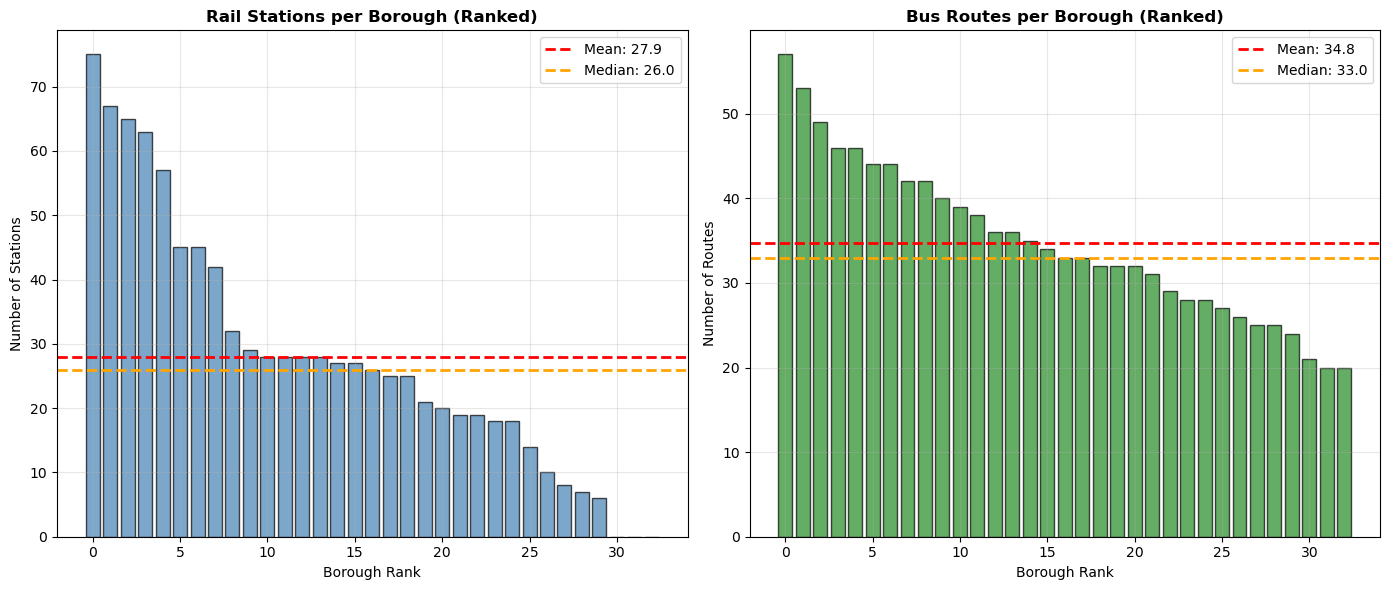


Key observation: Rail is highly concentrated (steep drop-off), buses more evenly distributed


In [33]:
# Visualize rail vs bus distribution patterns
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Rail stations distribution
axes[0].bar(range(len(df)), df.sort_values('station_count', ascending=False)['station_count'], 
            color='steelblue', alpha=0.7, edgecolor='black')
axes[0].axhline(df['station_count'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df["station_count"].mean():.1f}')
axes[0].axhline(df['station_count'].median(), color='orange', linestyle='--', linewidth=2, label=f'Median: {df["station_count"].median():.1f}')
axes[0].set_title('Rail Stations per Borough (Ranked)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Borough Rank')
axes[0].set_ylabel('Number of Stations')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 2. Bus routes distribution
axes[1].bar(range(len(df)), df.sort_values('bus_route_count', ascending=False)['bus_route_count'], 
            color='forestgreen', alpha=0.7, edgecolor='black')
axes[1].axhline(df['bus_route_count'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df["bus_route_count"].mean():.1f}')
axes[1].axhline(df['bus_route_count'].median(), color='orange', linestyle='--', linewidth=2, label=f'Median: {df["bus_route_count"].median():.1f}')
axes[1].set_title('Bus Routes per Borough (Ranked)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Borough Rank')
axes[1].set_ylabel('Number of Routes')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nKey observation: Rail is highly concentrated (steep drop-off), buses more evenly distributed")

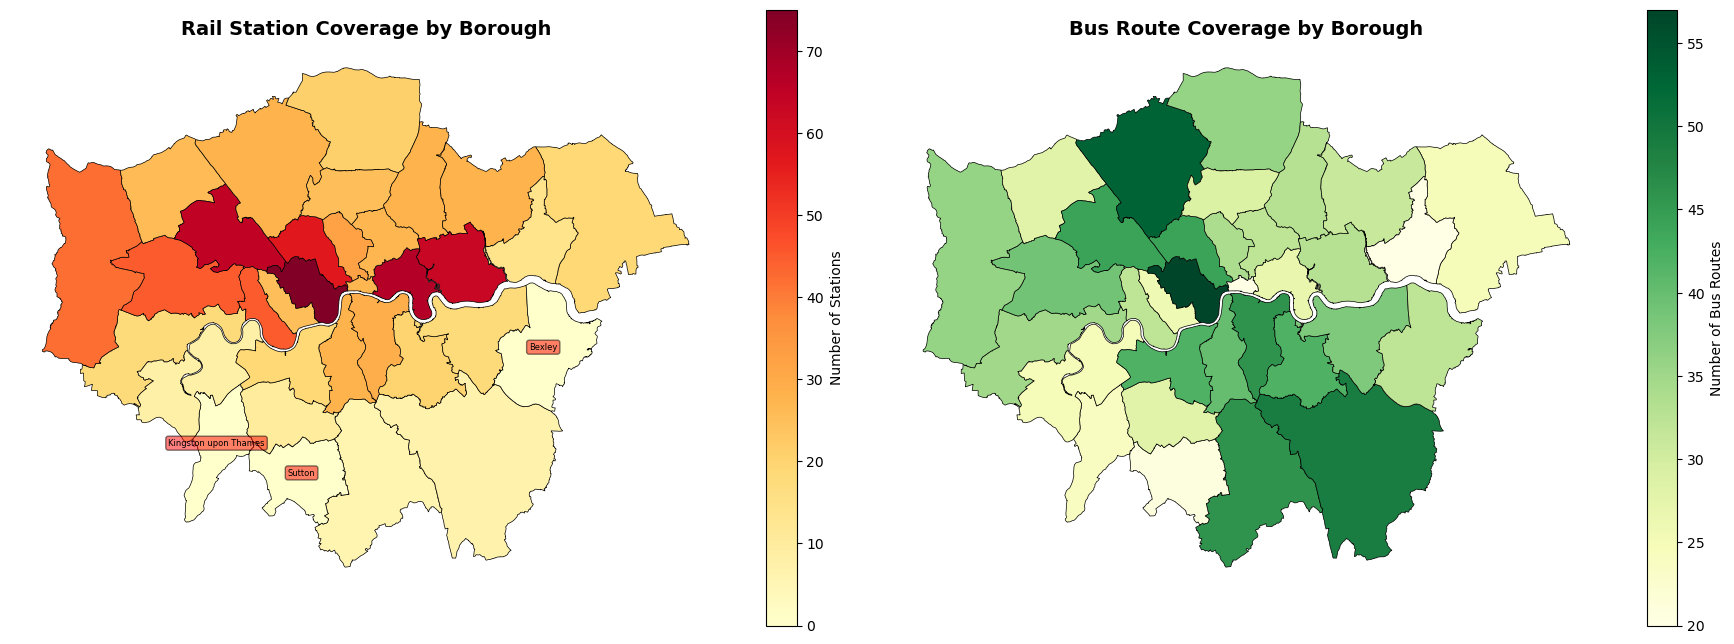

Rail coverage: Highly concentrated in central/north
Bus coverage: More evenly distributed across all boroughs


In [34]:


# Merge data with borough geometries
borough_map = boroughs.merge(df, left_on='NAME', right_on='borough_name')

# Create side-by-side maps
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# 1. Rail Stations Map
borough_map.plot(column='station_count', ax=axes[0], legend=True,
                 cmap='YlOrRd', edgecolor='black', linewidth=0.5,
                 legend_kwds={'label': 'Number of Stations', 'shrink': 0.8})
axes[0].set_title('Rail Station Coverage by Borough', fontsize=14, fontweight='bold')
axes[0].axis('off')

# Add borough labels for clarity
for idx, row in borough_map.iterrows():
    centroid = row.geometry.centroid
    if row['station_count'] == 0:  # Highlight zero-station boroughs
        axes[0].text(centroid.x, centroid.y, row['borough_name'], 
                    fontsize=6, ha='center', bbox=dict(boxstyle='round', facecolor='red', alpha=0.5))

# 2. Bus Routes Map
borough_map.plot(column='bus_route_count', ax=axes[1], legend=True,
                 cmap='YlGn', edgecolor='black', linewidth=0.5,
                 legend_kwds={'label': 'Number of Bus Routes', 'shrink': 0.8})
axes[1].set_title('Bus Route Coverage by Borough', fontsize=14, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()

print("Rail coverage: Highly concentrated in central/north")
print("Bus coverage: More evenly distributed across all boroughs")

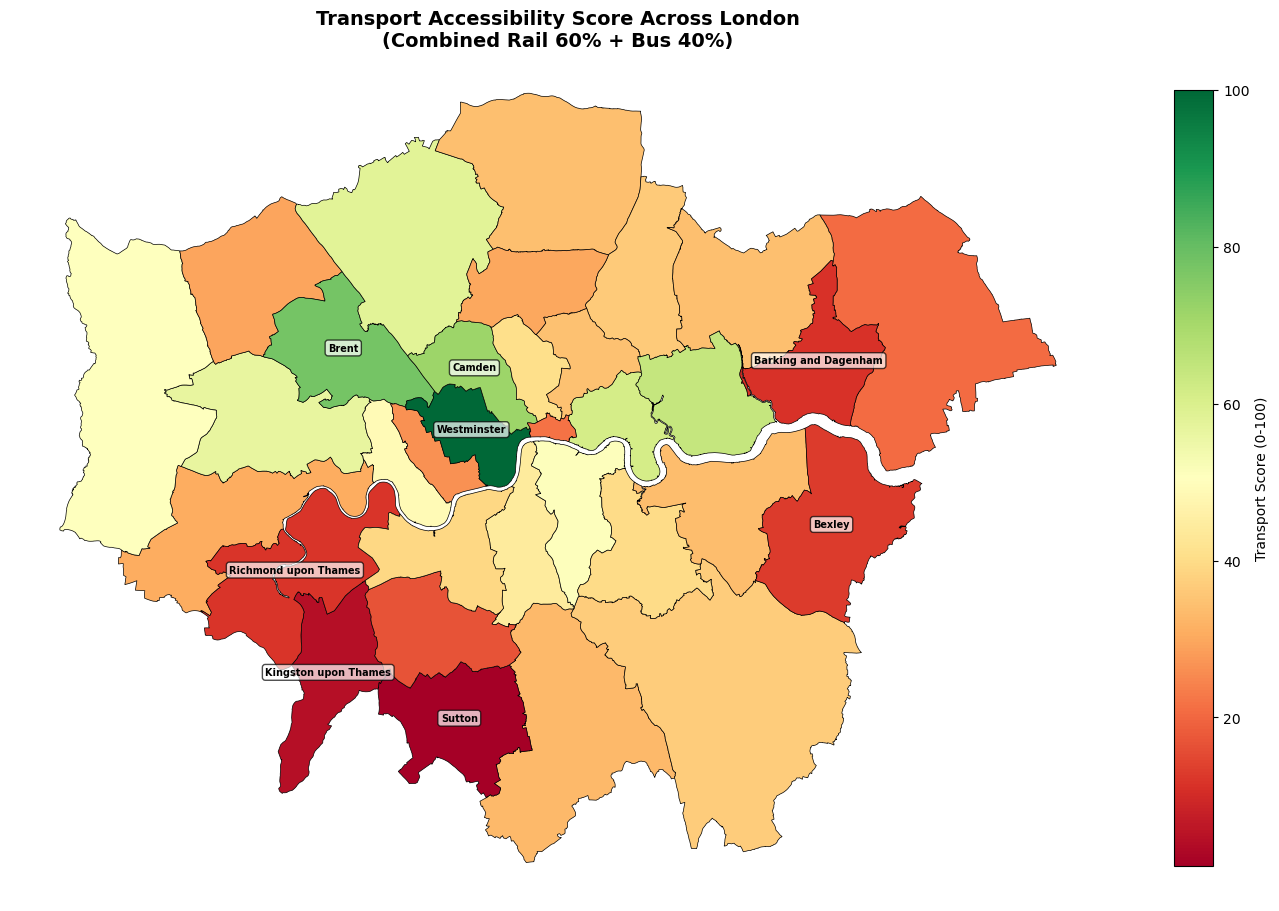


Best connected: borough_name  transport_score
 Westminster           100.00
       Brent            77.95
      Camden            71.55

Worst connected:         borough_name  transport_score
              Sutton             1.08
Kingston upon Thames             4.32
Barking and Dagenham            11.20


In [35]:
# Map: Overall Transport Accessibility
fig, ax = plt.subplots(figsize=(14, 10))

borough_map.plot(column='transport_score', ax=ax, legend=True,
                 cmap='RdYlGn', edgecolor='black', linewidth=0.5,
                 legend_kwds={'label': 'Transport Score (0-100)', 'shrink': 0.8})

# Add borough labels
for idx, row in borough_map.iterrows():
    centroid = row.geometry.centroid
    # Only label boroughs with extreme scores
    if row['transport_score'] > 70 or row['transport_score'] < 15:
        ax.text(centroid.x, centroid.y, row['borough_name'], 
               fontsize=7, ha='center', fontweight='bold',
               bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

ax.set_title('Transport Accessibility Score Across London\n(Combined Rail 60% + Bus 40%)', 
             fontsize=14, fontweight='bold')
ax.axis('off')

plt.tight_layout()
plt.show()

# Summary stats
print(f"\nBest connected: {df.nlargest(3, 'transport_score')[['borough_name', 'transport_score']].to_string(index=False)}")
print(f"\nWorst connected: {df.nsmallest(3, 'transport_score')[['borough_name', 'transport_score']].to_string(index=False)}")

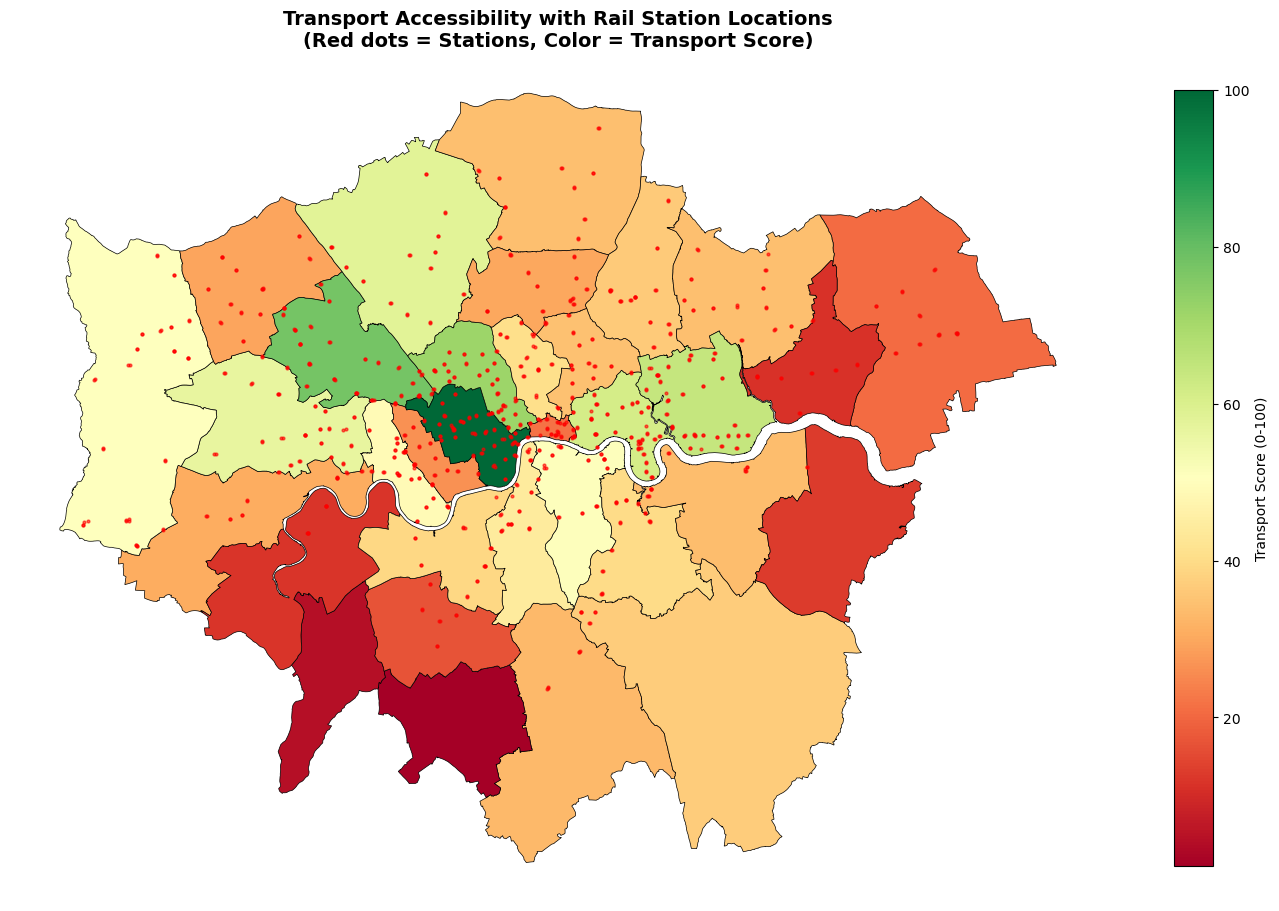

Mapped 917 rail stations across London
Visual shows: High transport scores correlate with dense station clusters


In [36]:
# Map: Transport Score with Station Points Overlaid
fig, ax = plt.subplots(figsize=(14, 10))

# Plot borough transport scores
borough_map.plot(column='transport_score', ax=ax, legend=True,
                 cmap='RdYlGn', edgecolor='black', linewidth=0.5,
                 legend_kwds={'label': 'Transport Score (0-100)', 'shrink': 0.8})

# Load and plot stations
stations = pd.read_csv('data/processed/tfl_stations_with_boroughs.csv')

# Convert stations to GeoDataFrame
from shapely.geometry import Point
stations_gdf = gpd.GeoDataFrame(
    stations,
    geometry=[Point(lon, lat) for lon, lat in zip(stations['lon'], stations['lat'])],
    crs='EPSG:4326'
)
stations_gdf = stations_gdf.to_crs(boroughs.crs)

# Plot stations as red points
stations_gdf.plot(ax=ax, color='red', markersize=4, alpha=0.6, zorder=5)

ax.set_title('Transport Accessibility with Rail Station Locations\n(Red dots = Stations, Color = Transport Score)', 
             fontsize=14, fontweight='bold')
ax.axis('off')

plt.tight_layout()
plt.show()

print(f"Mapped {len(stations)} rail stations across London")
print("Visual shows: High transport scores correlate with dense station clusters")

In [38]:
# Check bus stops file structure
bus_stops = pd.read_csv('data/processed/bus_stops_with_boroughs.csv')

print("Bus stops columns:")
print(bus_stops.columns.tolist())

print("\nFirst few rows:")
print(bus_stops.head())

Bus stops columns:
['route_id', 'stop_id', 'stop_name', 'lat', 'lon', 'geometry', 'index_right', 'NAME']

First few rows:
  route_id      stop_id                            stop_name       lat  \
0        1   490000020K                 Belsize Park Station  51.55070   
1        1   490000020L                 Belsize Park Station  51.55075   
2        1   490000036R  Camden Town Station / Camden Street  51.54000   
3        1  490000043CC                   Chalk Farm Station  51.54437   
4        1  490000043ZZ                   Chalk Farm Station  51.54375   

       lon                                      geometry  index_right    NAME  
0 -0.16528   POINT (527307.065606865 185129.37459460605)         25.0  Camden  
1 -0.16519  POINT (527313.1658059456 185135.09134275757)         25.0  Camden  
2 -0.14063   POINT (529046.2851714522 183982.6435625616)         25.0  Camden  
3 -0.15393     POINT (528111.72228272 184445.2489797761)         25.0  Camden  
4 -0.15209   POINT (528241.048134

Plotting 18,766 unique bus stop locations


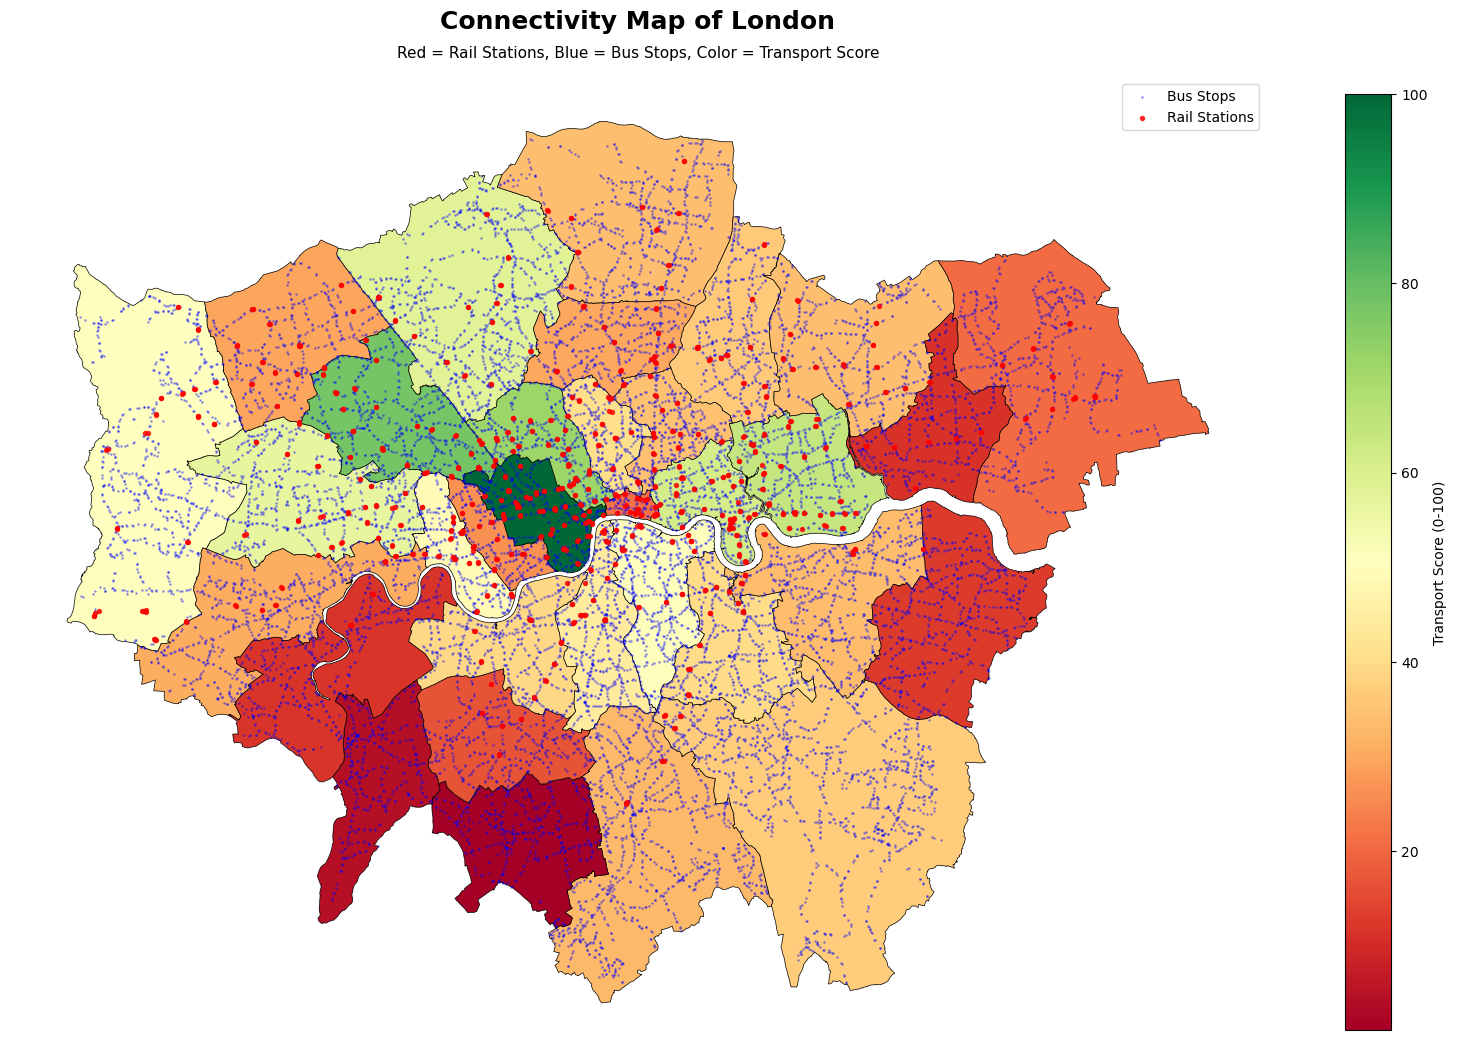


Mapped 917 rail stations and 18,766 bus stops


In [41]:
# Map: Transport Score with Stations AND Bus Stops
fig, ax = plt.subplots(figsize=(16, 12))

# Plot borough transport scores
borough_map.plot(column='transport_score', ax=ax, legend=True,
                 cmap='RdYlGn', edgecolor='black', linewidth=0.5,
                 legend_kwds={'label': 'Transport Score (0-100)', 'shrink': 0.8})

# Load bus stops (already loaded)
bus_stops_london = bus_stops[bus_stops['NAME'].notna()]

# Deduplicate bus stops by location (use lat/lon rounded)
bus_stops_london = bus_stops_london.drop_duplicates(subset=['lat', 'lon'])

print(f"Plotting {len(bus_stops_london):,} unique bus stop locations")

# Convert bus stops to GeoDataFrame
from shapely.geometry import Point
bus_stops_gdf = gpd.GeoDataFrame(
    bus_stops_london,
    geometry=[Point(lon, lat) for lon, lat in zip(bus_stops_london['lon'], bus_stops_london['lat'])],
    crs='EPSG:4326'
)
bus_stops_gdf = bus_stops_gdf.to_crs(boroughs.crs)

# Plot bus stops (smaller, semi-transparent)
bus_stops_gdf.plot(ax=ax, color='blue', markersize=1, alpha=0.3, zorder=4, label='Bus Stops')

# Plot rail stations (larger, more visible)
stations_gdf.plot(ax=ax, color='red', markersize=8, alpha=0.8, zorder=5, label='Rail Stations')

ax.text(0.5, 1.05, 'Connectivity Map of London', 
        fontsize=18, fontweight='bold', ha='center', transform=ax.transAxes)
ax.text(0.5, 1.02, 'Red = Rail Stations, Blue = Bus Stops, Color = Transport Score', 
        fontsize=11, ha='center', transform=ax.transAxes)
ax.legend(loc='upper right')
ax.axis('off')

plt.tight_layout()
plt.show()

print(f"\nMapped {len(stations)} rail stations and {len(bus_stops_london):,} bus stops")

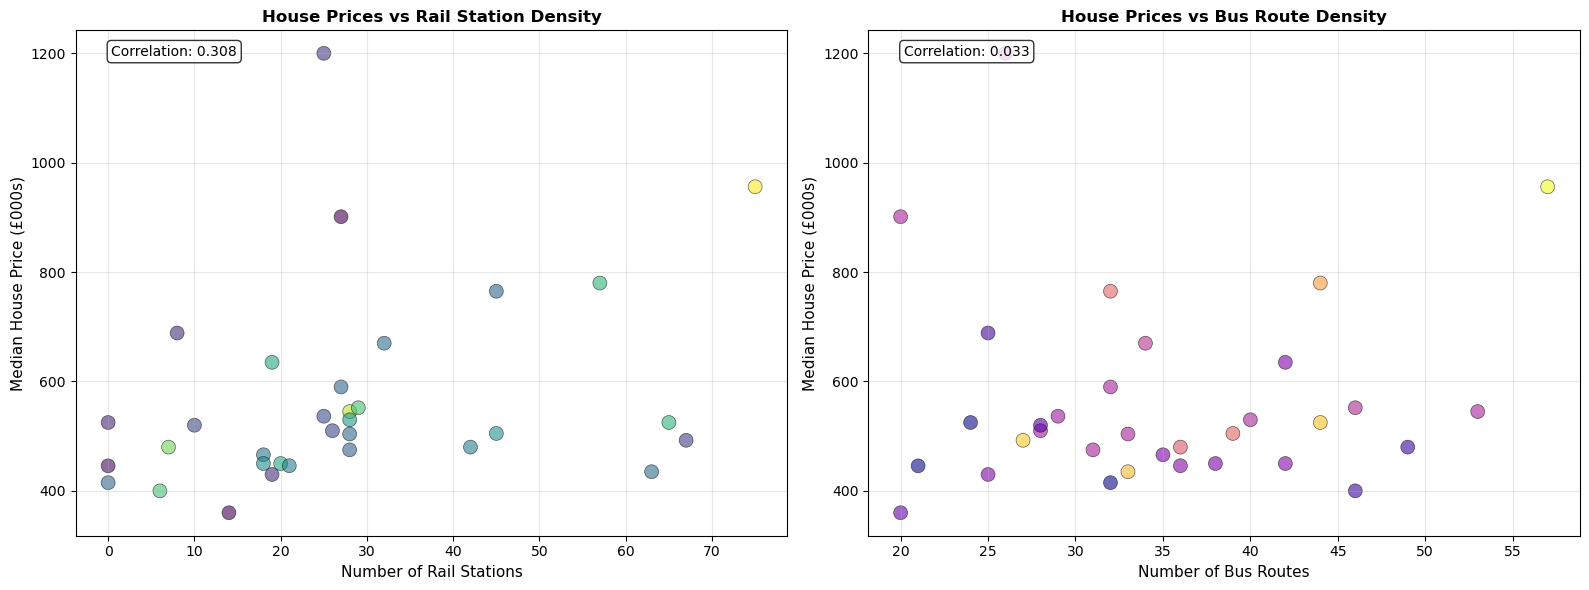

Rail vs Price correlation: 0.308
Bus vs Price correlation: 0.033

Objective finding: Rail connectivity has stronger relationship with house prices


In [42]:
# Scatter: House Price vs Transport Infrastructure
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Price vs Rail Stations
axes[0].scatter(df['station_count'], df['median_price']/1000, 
                s=100, alpha=0.6, c=df['bus_route_count'], 
                cmap='viridis', edgecolors='black', linewidth=0.5)
axes[0].set_xlabel('Number of Rail Stations', fontsize=11)
axes[0].set_ylabel('Median House Price (£000s)', fontsize=11)
axes[0].set_title('House Prices vs Rail Station Density', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Add correlation
corr_rail = df['station_count'].corr(df['median_price'])
axes[0].text(0.05, 0.95, f'Correlation: {corr_rail:.3f}', 
            transform=axes[0].transAxes, fontsize=10,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# 2. Price vs Bus Routes
axes[1].scatter(df['bus_route_count'], df['median_price']/1000, 
                s=100, alpha=0.6, c=df['station_count'], 
                cmap='plasma', edgecolors='black', linewidth=0.5)
axes[1].set_xlabel('Number of Bus Routes', fontsize=11)
axes[1].set_ylabel('Median House Price (£000s)', fontsize=11)
axes[1].set_title('House Prices vs Bus Route Density', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

corr_bus = df['bus_route_count'].corr(df['median_price'])
axes[1].text(0.05, 0.95, f'Correlation: {corr_bus:.3f}', 
            transform=axes[1].transAxes, fontsize=10,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

print(f"Rail vs Price correlation: {corr_rail:.3f}")
print(f"Bus vs Price correlation: {corr_bus:.3f}")
print(f"\nObjective finding: {'Rail' if abs(corr_rail) > abs(corr_bus) else 'Bus'} connectivity has stronger relationship with house prices")

In [43]:
# Analyze transport mode types by borough
print("Transport Mode Type Breakdown by Borough\n")

# Load stations
stations = pd.read_csv('data/processed/tfl_stations_with_boroughs.csv')

print(f"Total stations: {len(stations)}")
print(f"\nSample modes column:")
print(stations['modes'].value_counts().head(10))

# Parse modes - split comma-separated values
stations_expanded = stations.copy()

# Check for each mode type
mode_types = ['tube', 'overground', 'dlr', 'elizabeth-line', 'national-rail']

for mode in mode_types:
    stations_expanded[f'has_{mode}'] = stations_expanded['modes'].str.contains(mode, case=False, na=False)

print(f"\n--- Mode Presence Across All Stations ---")
for mode in mode_types:
    count = stations_expanded[f'has_{mode}'].sum()
    print(f"{mode:15s}: {count:4d} stations ({count/len(stations)*100:.1f}%)")

# Aggregate by borough
mode_by_borough = stations_expanded.groupby('borough')[
    [f'has_{mode}' for mode in mode_types]
].sum().reset_index()

# Rename columns
mode_by_borough.columns = ['borough'] + [f'{mode}_count' for mode in mode_types]

# Show top boroughs for each mode
print("\n--- Top 5 Boroughs by Tube Stations ---")
print(mode_by_borough.nlargest(5, 'tube_count')[['borough', 'tube_count']])

print("\n--- Top 5 Boroughs by Overground Stations ---")
print(mode_by_borough.nlargest(5, 'overground_count')[['borough', 'overground_count']])

print("\n--- Top 5 Boroughs by DLR Stations ---")
print(mode_by_borough.nlargest(5, 'dlr_count')[['borough', 'dlr_count']])

print("\n--- Elizabeth Line Coverage ---")
print(mode_by_borough[mode_by_borough['elizabeth-line_count'] > 0][['borough', 'elizabeth-line_count']].sort_values('elizabeth-line_count', ascending=False))

Transport Mode Type Breakdown by Borough

Total stations: 917

Sample modes column:
modes
tube                            489
overground                      167
dlr                              86
overground,national-rail         33
elizabeth-line                   31
elizabeth-line,national-rail     14
national-rail,overground         10
national-rail,elizabeth-line      6
overground,bus                    5
bus,tube,overground               4
Name: count, dtype: int64

--- Mode Presence Across All Stations ---
tube           :  542 stations (59.1%)
overground     :  255 stations (27.8%)
dlr            :   99 stations (10.8%)
elizabeth-line :   60 stations (6.5%)
national-rail  :  116 stations (12.6%)

--- Top 5 Boroughs by Tube Stations ---
                   borough  tube_count
29             Westminster          71
2                    Brent          41
4                   Camden          37
11  Hammersmith and Fulham          33
15              Hillingdon          33

--- Top 5 B

In [44]:
# Population-weighted transport access
print("Population Impact Analysis\n")

total_pop = df['population'].sum()
print(f"Total London population (33 boroughs): {total_pop:,}")

# Define connectivity tiers
df['connectivity_tier'] = pd.cut(df['transport_score'], 
                                  bins=[0, 20, 40, 60, 100],
                                  labels=['Poor (0-20)', 'Moderate (20-40)', 
                                          'Good (40-60)', 'Excellent (60+)'])

# Calculate population in each tier
tier_population = df.groupby('connectivity_tier', observed=True).agg({
    'population': 'sum',
    'borough_name': 'count'
}).reset_index()

tier_population.columns = ['connectivity_tier', 'total_population', 'num_boroughs']
tier_population['percent_population'] = (tier_population['total_population'] / total_pop * 100).round(1)

print("Population Distribution by Transport Connectivity:")
print(tier_population)

# Specific findings
poor_transport_pop = df[df['transport_score'] < 20]['population'].sum()
excellent_transport_pop = df[df['transport_score'] > 60]['population'].sum()

print(f"\nKey findings:")
print(f"  Population in poorly connected areas (<20): {poor_transport_pop:,} ({poor_transport_pop/total_pop*100:.1f}%)")
print(f"  Population in excellently connected areas (>60): {excellent_transport_pop:,} ({excellent_transport_pop/total_pop*100:.1f}%)")

# Which boroughs?
print(f"\nPoorly connected boroughs:")
print(df[df['transport_score'] < 20][['borough_name', 'population', 'transport_score']])

print(f"\nExcellently connected boroughs:")
print(df[df['transport_score'] > 60][['borough_name', 'population', 'transport_score']].sort_values('population', ascending=False))

Population Impact Analysis

Total London population (33 boroughs): 11,208,247
Population Distribution by Transport Connectivity:
  connectivity_tier  total_population  num_boroughs  percent_population
0       Poor (0-20)           1580428             6                14.1
1  Moderate (20-40)           5047128            15                45.0
2      Good (40-60)           2662995             7                23.8
3   Excellent (60+)           1917696             5                17.1

Key findings:
  Population in poorly connected areas (<20): 1,580,428 (14.1%)
  Population in excellently connected areas (>60): 1,917,696 (17.1%)

Poorly connected boroughs:
            borough_name  population  transport_score
0   Kingston upon Thames      228514             4.32
14                Bexley      304657            12.97
18                Sutton      242239             1.08
19  Richmond upon Thames      227030            11.81
20                Merton      255498            16.65
31  Barking

In [45]:
# Parse and analyze different rail mode types
print("Mode Type Distribution by Borough\n")

# Count each mode type per borough
mode_counts = []

for mode in mode_types:
    mode_df = stations_expanded[stations_expanded[f'has_{mode}']].groupby('borough').size().reset_index(name=f'{mode}_stations')
    mode_counts.append(mode_df)

# Merge all mode counts
mode_summary = mode_counts[0]
for mode_df in mode_counts[1:]:
    mode_summary = mode_summary.merge(mode_df, on='borough', how='outer')

mode_summary = mode_summary.fillna(0)
mode_summary.columns = ['borough'] + [f'{mode}_count' for mode in mode_types]

# Calculate dominant mode for each borough
mode_cols = [f'{mode}_count' for mode in mode_types]
mode_summary['dominant_mode'] = mode_summary[mode_cols].idxmax(axis=1).str.replace('_count', '')
mode_summary['total_stations'] = mode_summary[mode_cols].sum(axis=1)

print("Boroughs by Dominant Mode Type:")
print(mode_summary.sort_values('total_stations', ascending=False)[['borough', 'tube_count', 'overground_count', 'dlr_count', 'elizabeth-line_count', 'dominant_mode']].head(15))

print("\n--- Tube-Dominated Boroughs ---")
tube_boroughs = mode_summary[mode_summary['dominant_mode'] == 'tube'].sort_values('tube_count', ascending=False)
print(tube_boroughs[['borough', 'tube_count', 'overground_count']].head(10))

print("\n--- DLR-Heavy Boroughs (East London) ---")
dlr_boroughs = mode_summary.nlargest(5, 'dlr_count')
print(dlr_boroughs[['borough', 'dlr_count', 'tube_count']])

print("\n--- Elizabeth Line Corridor ---")
elizabeth_boroughs = mode_summary[mode_summary['elizabeth-line_count'] > 0].sort_values('elizabeth-line_count', ascending=False)
print(elizabeth_boroughs[['borough', 'elizabeth-line_count']])

Mode Type Distribution by Borough

Boroughs by Dominant Mode Type:
                   borough  tube_count  overground_count  dlr_count  \
29             Westminster        71.0               0.0        0.0   
2                    Brent        41.0              33.0        0.0   
22                  Newham        12.0               7.0       41.0   
26           Tower Hamlets        18.0              12.0       35.0   
4                   Camden        37.0              20.0        0.0   
15              Hillingdon        33.0               0.0        0.0   
7                   Ealing        31.0               4.0        0.0   
11  Hammersmith and Fulham        33.0              13.0        0.0   
25               Southwark        14.0              17.0        0.0   
17               Islington        21.0              11.0        0.0   
10                 Hackney         2.0              25.0        0.0   
5           City of London        20.0               1.0        6.0   
27        

C:\Users\dhruv\AppData\Local\Temp\ipykernel_22484\1669826510.py:22: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(title='Dominant Mode', loc='upper left')
C:\Users\dhruv\AppData\Local\Temp\ipykernel_22484\1669826510.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='Dominant Mode', loc='upper left')


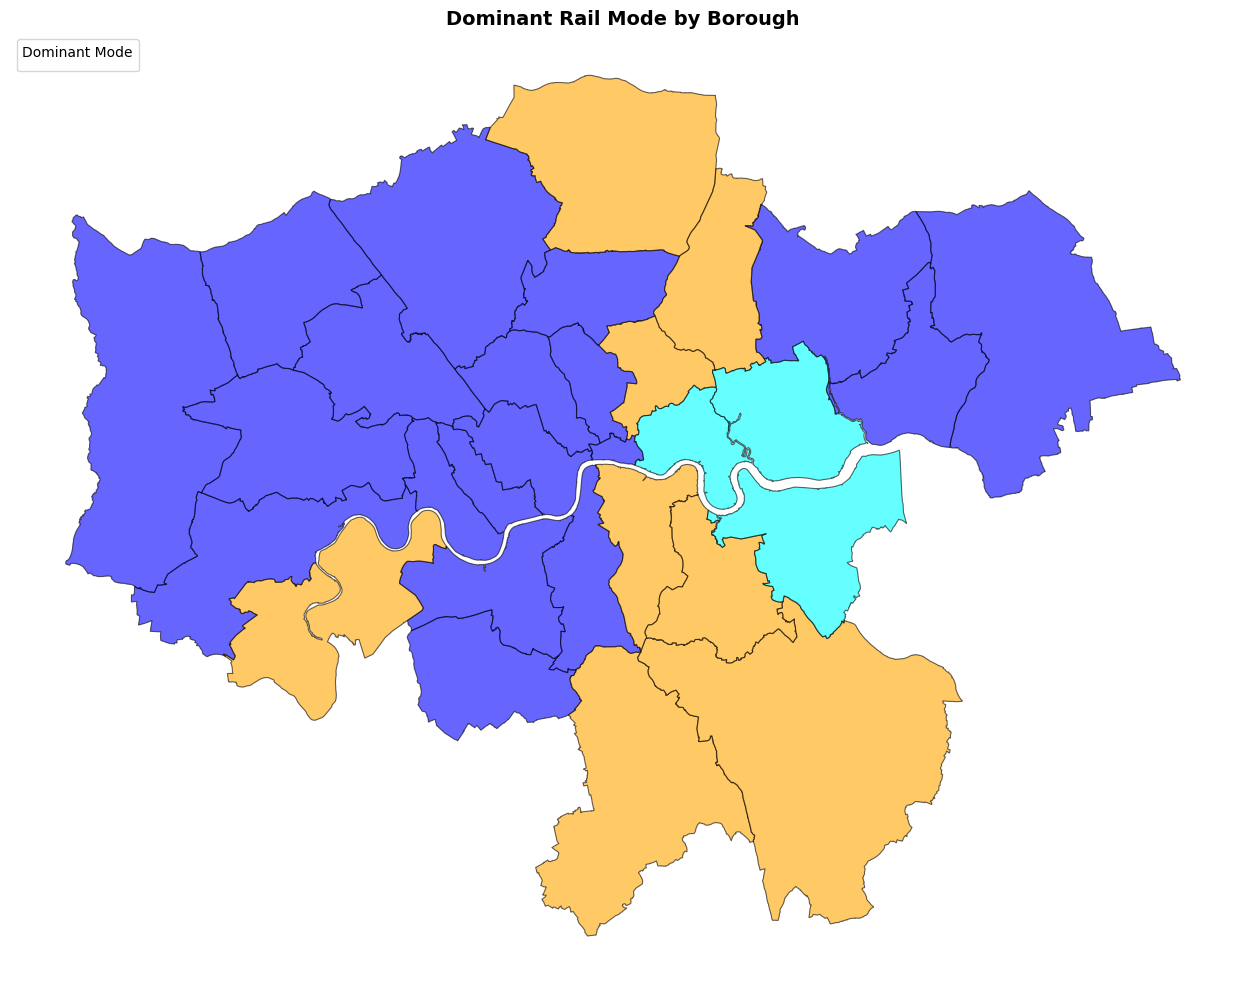

Geographic pattern:
  - Central/West: Tube-dominated (blue)
  - East: DLR-heavy (cyan)
  - Scattered: Overground connections (orange)


In [46]:
# Map: Dominant Transport Mode by Borough
fig, ax = plt.subplots(figsize=(14, 10))

# Merge mode data
borough_map_modes = boroughs.merge(mode_summary, left_on='NAME', right_on='borough')

# Create color map for modes
mode_colors = {'tube': 'blue', 'overground': 'orange', 'dlr': 'cyan', 
               'elizabeth-line': 'purple', 'national-rail': 'gray'}

# Plot with dominant mode colors
borough_map_modes['mode_color'] = borough_map_modes['dominant_mode'].map(mode_colors)

# Plot boroughs colored by dominant mode
for mode in mode_colors.keys():
    subset = borough_map_modes[borough_map_modes['dominant_mode'] == mode]
    if len(subset) > 0:
        subset.plot(ax=ax, color=mode_colors[mode], edgecolor='black', 
                   linewidth=0.8, alpha=0.6, label=mode.title())

ax.set_title('Dominant Rail Mode by Borough', fontsize=14, fontweight='bold')
ax.legend(title='Dominant Mode', loc='upper left')
ax.axis('off')

plt.tight_layout()
plt.show()

print("Geographic pattern:")
print("  - Central/West: Tube-dominated (blue)")
print("  - East: DLR-heavy (cyan)")
print("  - Scattered: Overground connections (orange)")

Transport Equity Analysis: Income and Rail/Bus Dependency

Correlation (Income vs Rail Stations): -0.121
Correlation (Income vs Bus Routes): 0.184

--- Income Comparison ---
Boroughs WITH rail stations:
  Mean earnings: £20.41/hr
  Median earnings: £20.10/hr
  Count: 29 boroughs

Boroughs WITHOUT rail stations (bus-only):
  Mean earnings: £20.15/hr
  Median earnings: £20.13/hr
  Count: 3 boroughs

Bus-only boroughs: ['Kingston upon Thames', 'Bexley', 'Sutton']


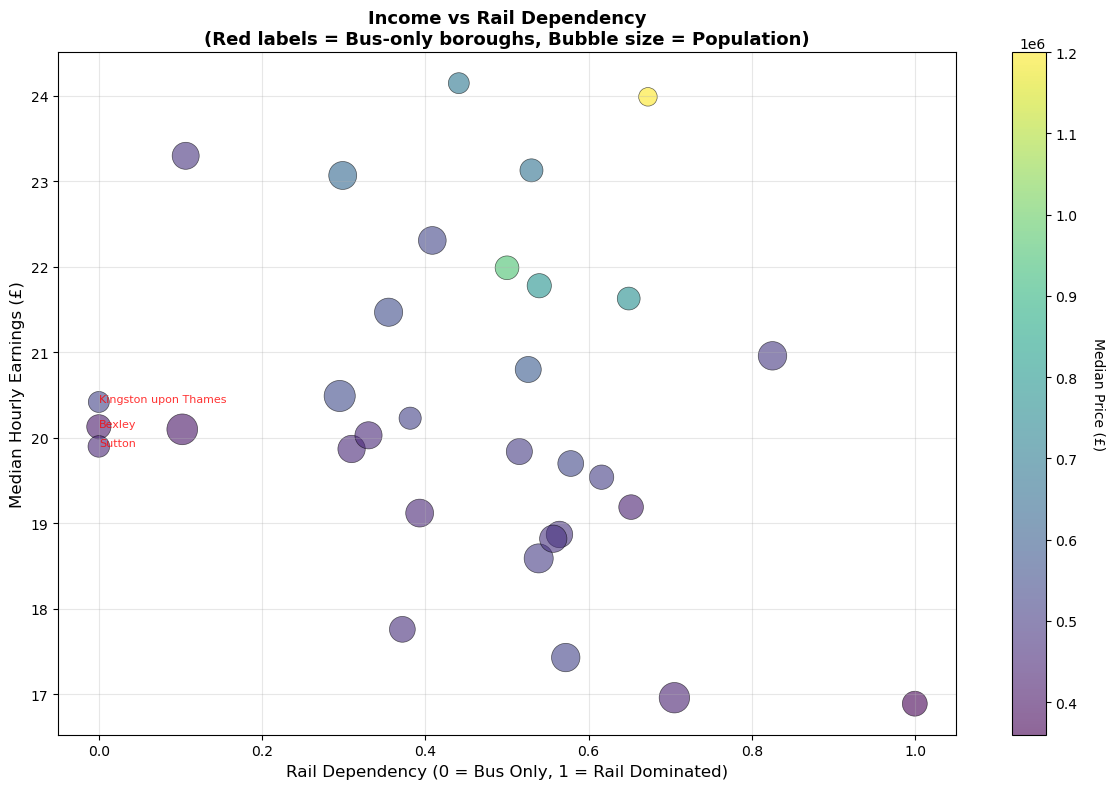


Conclusion: Do poorer areas lack rail access?


In [47]:
# Income vs Rail Access Analysis
print("Transport Equity Analysis: Income and Rail/Bus Dependency\n")

df_income = df.dropna(subset=['median_hourly_earnings'])

# Correlations
corr_income_rail = df_income['median_hourly_earnings'].corr(df_income['station_count'])
corr_income_bus = df_income['median_hourly_earnings'].corr(df_income['bus_route_count'])

print(f"Correlation (Income vs Rail Stations): {corr_income_rail:.3f}")
print(f"Correlation (Income vs Bus Routes): {corr_income_bus:.3f}")

# Compare income between rail-served vs bus-only
rail_served = df_income[df_income['station_count'] > 0]
bus_only = df_income[df_income['station_count'] == 0]

print(f"\n--- Income Comparison ---")
print(f"Boroughs WITH rail stations:")
print(f"  Mean earnings: £{rail_served['median_hourly_earnings'].mean():.2f}/hr")
print(f"  Median earnings: £{rail_served['median_hourly_earnings'].median():.2f}/hr")
print(f"  Count: {len(rail_served)} boroughs")

print(f"\nBoroughs WITHOUT rail stations (bus-only):")
print(f"  Mean earnings: £{bus_only['median_hourly_earnings'].mean():.2f}/hr")
print(f"  Median earnings: £{bus_only['median_hourly_earnings'].median():.2f}/hr")
print(f"  Count: {len(bus_only)} boroughs")
print(f"\nBus-only boroughs: {bus_only['borough_name'].tolist()}")

# Scatter: Earnings vs Rail Dependency Ratio
fig, ax = plt.subplots(figsize=(12, 8))

scatter = ax.scatter(df_income['rail_dependency'], df_income['median_hourly_earnings'], 
                     s=df_income['population']/1000, alpha=0.6,
                     c=df_income['median_price'], cmap='viridis',
                     edgecolors='black', linewidth=0.5)

# Label bus-only boroughs
for idx, row in df_income.iterrows():
    if row['station_count'] == 0:
        ax.annotate(row['borough_name'], 
                   (row['rail_dependency'], row['median_hourly_earnings']),
                   fontsize=8, alpha=0.8, color='red')

ax.set_xlabel('Rail Dependency (0 = Bus Only, 1 = Rail Dominated)', fontsize=12)
ax.set_ylabel('Median Hourly Earnings (£)', fontsize=12)
ax.set_title('Income vs Rail Dependency\n(Red labels = Bus-only boroughs, Bubble size = Population)', 
             fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Median Price (£)', rotation=270, labelpad=20)

plt.tight_layout()
plt.show()

print(f"\nConclusion: Do poorer areas lack rail access?")

Modal Equity Analysis: Earnings by Rail Type

Correlations (Earnings vs Mode Percentage):
  Tube percentage: 0.081
  Overground percentage: 0.122
  DLR percentage: -0.205

--- Mean Earnings by Dominant Mode ---
                    mean  count
dominant_mode                  
dlr            19.316667      3
overground     21.081250      8
tube           20.300556     18


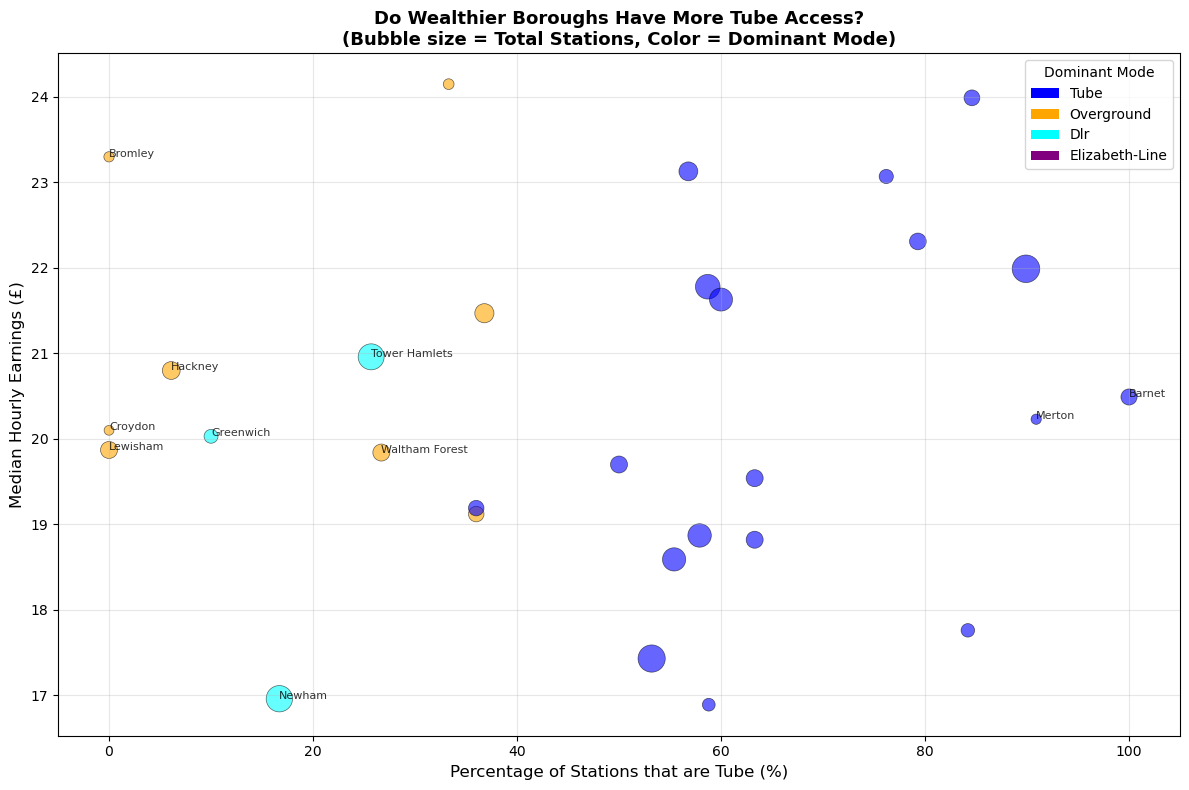

In [48]:
# Do wealthier boroughs have tube while poorer areas rely on overground/DLR?
print("Modal Equity Analysis: Earnings by Rail Type\n")

# Merge earnings data with mode summary
mode_earnings = mode_summary.merge(
    df[['borough_name', 'median_hourly_earnings']], 
    left_on='borough', 
    right_on='borough_name'
).dropna(subset=['median_hourly_earnings'])

# Calculate mode proportions
mode_earnings['tube_pct'] = (mode_earnings['tube_count'] / mode_earnings['total_stations'] * 100).round(1)
mode_earnings['overground_pct'] = (mode_earnings['overground_count'] / mode_earnings['total_stations'] * 100).round(1)
mode_earnings['dlr_pct'] = (mode_earnings['dlr_count'] / mode_earnings['total_stations'] * 100).round(1)

# Correlations
print("Correlations (Earnings vs Mode Percentage):")
print(f"  Tube percentage: {mode_earnings['tube_pct'].corr(mode_earnings['median_hourly_earnings']):.3f}")
print(f"  Overground percentage: {mode_earnings['overground_pct'].corr(mode_earnings['median_hourly_earnings']):.3f}")
print(f"  DLR percentage: {mode_earnings['dlr_pct'].corr(mode_earnings['median_hourly_earnings']):.3f}")

# Compare by dominant mode
print("\n--- Mean Earnings by Dominant Mode ---")
earnings_by_mode = mode_earnings.groupby('dominant_mode')['median_hourly_earnings'].agg(['mean', 'count'])
print(earnings_by_mode)

# Scatter plot
fig, ax = plt.subplots(figsize=(12, 8))

# Color by dominant mode
mode_colors_map = {'tube': 'blue', 'overground': 'orange', 'dlr': 'cyan', 'elizabeth-line': 'purple'}
colors = mode_earnings['dominant_mode'].map(mode_colors_map)

scatter = ax.scatter(mode_earnings['tube_pct'], mode_earnings['median_hourly_earnings'],
                     s=mode_earnings['total_stations']*5, alpha=0.6,
                     c=colors, edgecolors='black', linewidth=0.5)

# Label interesting points
for idx, row in mode_earnings.iterrows():
    if row['tube_pct'] < 30 or row['tube_pct'] > 90:
        ax.annotate(row['borough'], 
                   (row['tube_pct'], row['median_hourly_earnings']),
                   fontsize=8, alpha=0.8)

ax.set_xlabel('Percentage of Stations that are Tube (%)', fontsize=12)
ax.set_ylabel('Median Hourly Earnings (£)', fontsize=12)
ax.set_title('Do Wealthier Boroughs Have More Tube Access?\n(Bubble size = Total Stations, Color = Dominant Mode)', 
             fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)

# Manual legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=color, label=mode.title()) 
                   for mode, color in mode_colors_map.items()]
ax.legend(handles=legend_elements, title='Dominant Mode')

plt.tight_layout()
plt.show()